[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AveriX26/ML-Course-2026/blob/main/zad_dom_3.ipynb)

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

X, y = load_breast_cancer(return_X_y=True, as_frame=True)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)

print("Rozmiary zbiorów:")
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print("\nProporcje klas:")
print("Train:\n", y_train.value_counts(normalize=True).sort_index())
print("Val:\n", y_val.value_counts(normalize=True).sort_index())
print("Test:\n", y_test.value_counts(normalize=True).sort_index())

model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, random_state=42))
])

model.fit(X_train, y_train)

val_prob = model.predict_proba(X_val)[:, 1]
test_prob = model.predict_proba(X_test)[:, 1]

Rozmiary zbiorów:
Train: (341, 30), Val: (114, 30), Test: (114, 30)

Proporcje klas:
Train:
 target
0    0.372434
1    0.627566
Name: proportion, dtype: float64
Val:
 target
0    0.377193
1    0.622807
Name: proportion, dtype: float64
Test:
 target
0    0.368421
1    0.631579
Name: proportion, dtype: float64


In [ ]:
fpr, tpr, thresholds = roc_curve(y_val, val_prob)
auc_val = roc_auc_score(y_val, val_prob)

youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]

print(f"AUC (validation): {auc_val:.6f}")
print(f"Best threshold by Youden's J: {best_threshold:.6f}")
print(f"At best threshold: TPR={tpr[best_idx]:.6f}, FPR={fpr[best_idx]:.6f}, J={youden_j[best_idx]:.6f}")

def classification_metrics(y_true, prob, threshold):
    pred = (prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    acc = accuracy_score(y_true, pred)
    prec = precision_score(y_true, pred, zero_division=0)
    rec = recall_score(y_true, pred, zero_division=0)
    f1 = f1_score(y_true, pred, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    return {
        "threshold": threshold,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "specificity": specificity,
        "sensitivity": sensitivity,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }

val_metrics_05 = classification_metrics(y_val, val_prob, 0.5)
val_metrics_best = classification_metrics(y_val, val_prob, best_threshold)

print("\nWalidacja dla threshold=0.5:")
for k, v in val_metrics_05.items():
    print(f"{k}: {v}")

print("\nWalidacja dla threshold optymalnego:")
for k, v in val_metrics_best.items():
    print(f"{k}: {v}")

AUC (validation): 0.998035
Best threshold by Youden's J: 0.502879
At best threshold: TPR=1.000000, FPR=0.023256, J=0.976744

Walidacja dla threshold=0.5:
threshold: 0.5
accuracy: 0.9912280701754386
precision: 0.9861111111111112
recall: 1.0
f1: 0.993006993006993
specificity: 0.9767441860465116
sensitivity: 1.0
tn: 42
fp: 1
fn: 0
tp: 71

Walidacja dla threshold optymalnego:
threshold: 0.5028788536509972
accuracy: 0.9912280701754386
precision: 0.9861111111111112
recall: 1.0
f1: 0.993006993006993
specificity: 0.9767441860465116
sensitivity: 1.0
tn: 42
fp: 1
fn: 0
tp: 71


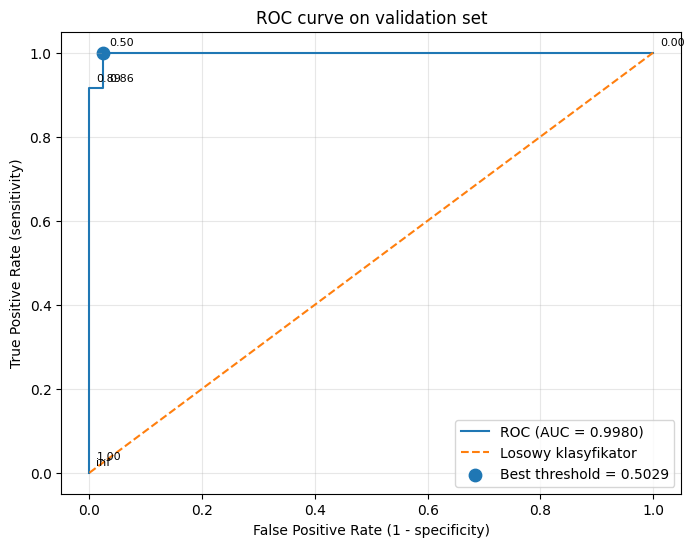

In [4]:
# Cell 3: wykres ROC z zaznaczonym progiem

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC (AUC = {auc_val:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Losowy klasyfikator")

# zaznaczenie najlepszego punktu
plt.scatter(fpr[best_idx], tpr[best_idx], s=80, label=f"Best threshold = {best_threshold:.4f}")

# opcjonalnie podpis kilku punktów progowych
for idx in np.linspace(0, len(thresholds) - 1, 6, dtype=int):
    plt.annotate(f"{thresholds[idx]:.2f}", (fpr[idx], tpr[idx]), textcoords="offset points", xytext=(5, 5), fontsize=8)

plt.xlabel("False Positive Rate (1 - specificity)")
plt.ylabel("True Positive Rate (sensitivity)")
plt.title("ROC curve on validation set")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# Cell 4: końcowa ocena na teście

test_metrics_05 = classification_metrics(y_test, test_prob, 0.5)
test_metrics_best = classification_metrics(y_test, test_prob, best_threshold)

print("TEST dla threshold=0.5:")
for k, v in test_metrics_05.items():
    print(f"{k}: {v}")

print("\nTEST dla threshold optymalnego:")
for k, v in test_metrics_best.items():
    print(f"{k}: {v}")

TEST dla threshold=0.5:
threshold: 0.5
accuracy: 0.9824561403508771
precision: 0.9861111111111112
recall: 0.9861111111111112
f1: 0.9861111111111112
specificity: 0.9761904761904762
sensitivity: 0.9861111111111112
tn: 41
fp: 1
fn: 1
tp: 71

TEST dla threshold optymalnego:
threshold: 0.5028788536509972
accuracy: 0.9824561403508771
precision: 0.9861111111111112
recall: 0.9861111111111112
f1: 0.9861111111111112
specificity: 0.9761904761904762
sensitivity: 0.9861111111111112
tn: 41
fp: 1
fn: 1
tp: 71


In [6]:
# Cell 5: porównanie 0.5 vs próg optymalny na teście w tabeli

results_test = pd.DataFrame([
    test_metrics_05,
    test_metrics_best
], index=["threshold=0.5", "threshold=best_by_Youden"])

results_test

,threshold,accuracy,precision,recall,f1,specificity,sensitivity,tn,fp,fn,tp
threshold=0.5,0.500000,0.982456,0.986111,0.986111,0.986111,0.97619,0.986111,41,1,1,71
threshold=best_by_Youden,0.502879,0.982456,0.986111,0.986111,0.986111,0.97619,0.986111,41,1,1,71


## Dobór progu decyzyjnego na podstawie krzywej ROC

W tym zadaniu próg klasyfikacji nie jest ustalony na stałe (np. 0.5),  
ale dobierany na podstawie krzywej ROC przy użyciu zbioru walidacyjnego.

Krzywa ROC przedstawia zależność pomiędzy:
- czułością (TPR – True Positive Rate)
- odsetkiem fałszywie pozytywnych (FPR – False Positive Rate)

Optymalny próg został wyznaczony przy użyciu statystyki Youdena:

J = TPR - FPR

Próg maksymalizujący J zapewnia najlepszy kompromis pomiędzy czułością i specyficznością.

### 1. Czy inny próg może dać lepszy wynik?

W ogólności tak — zmiana progu może poprawić wyniki modelu w zależności od wybranej metryki.

Jednak w tym przypadku:
- optymalny próg ≈ 0.503 jest praktycznie równy 0.5
- metryki dla obu progów są identyczne zarówno na zbiorze walidacyjnym, jak i testowym

Dowody:
- identyczne accuracy, precision, recall i F1
- taka sama macierz pomyłek na teście (TN=41, FP=1, FN=1, TP=71)

Oznacza to, że zmiana progu nie poprawia jakości modelu.

### 2. Co oznacza „lepszy” wynik?

„Lepszy” wynik zależy od kontekstu problemu oraz wybranej metryki.

Przykłady:
- wysoka czułość (recall) jest ważna, gdy nie chcemy przeoczyć pozytywnych przypadków
- wysoka specyficzność jest ważna, gdy chcemy ograniczyć fałszywe alarmy

W tym zadaniu:
- recall ≈ 0.986
- specificity ≈ 0.976

Obie wartości są bardzo wysokie, więc model działa dobrze niezależnie od przyjętego progu.

### 3. Jak pomaga krzywa ROC?

Krzywa ROC pokazuje działanie modelu dla wszystkich możliwych progów klasyfikacji.

Z wykresu wynika, że:
- krzywa przebiega bardzo blisko lewego górnego rogu
- AUC ≈ 0.998, co oznacza niemal idealną klasyfikację

Wnioski:
- model bardzo dobrze rozdziela klasy
- istnieje szeroki zakres progów, dla których wyniki są bardzo podobne

Dlatego wybór konkretnego progu nie ma w tym przypadku dużego znaczenia.

### 4. Jak wybrano optymalny próg?

Optymalny próg został wyznaczony przy użyciu statystyki Youdena:

J = TPR - FPR

Na zbiorze walidacyjnym:
- najlepszy próg ≈ 0.503
- TPR = 1.0 (brak fałszywych negatywów)
- FPR ≈ 0.023 (bardzo mało fałszywych pozytywów)

Oznacza to bardzo dobry kompromis pomiędzy czułością i specyficznością.

### 5. Co to jest AUC i do czego służy?

AUC (Area Under the Curve) to pole pod krzywą ROC.

W tym przypadku:
- AUC ≈ 0.998

Oznacza to, że model niemal idealnie rozróżnia klasy.

AUC jest użyteczne, ponieważ:
- nie zależy od konkretnego progu
- pozwala ocenić ogólną jakość modelu

Wysoka wartość AUC tłumaczy, dlaczego zmiana progu nie wpływa na wyniki.

## Wnioski końcowe

Model osiąga bardzo wysoką jakość:
- accuracy ≈ 0.982
- F1 ≈ 0.986
- tylko 2 błędy na zbiorze testowym

Krzywa ROC oraz AUC wskazują na niemal idealną zdolność rozróżniania klas.

W związku z tym:
- optymalny próg (~0.503) jest bardzo bliski 0.5
- zmiana progu nie wpływa na wyniki klasyfikacji

Oznacza to, że model działa w stabilnym obszarze, w którym niewielkie zmiany progu nie zmieniają decyzji klasyfikacyjnych.